# 다변량 정규분포

## 정의
**다변량 정규분포**는 정규분포를 다차원으로 일반화한 것으로 다음과 같이 정의된다:

$$
f(x) = \frac{1}{(2\pi)^{d/2} |\Sigma|^{1/2}} \exp\left(-\frac{1}{2} (x - \mu)^T \Sigma^{-1} (x - \mu)\right)
$$

- $ \mu $: 평균 벡터 ($d$-차원)
- $ \Sigma $: 공분산 행렬 ($d \times d$, 대칭이고 양의 정부호 행렬)
- $ x $: $d$-차원 벡터

## 속성
1. **평균**: $ \mathbb{E}[X] = \mu $
2. **공분산**: $ \text{Cov}(X) = \Sigma $
3. **주변 분포 및 조건부 분포**도 정규분포이다.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

In [4]:
plt.rcParams.update({'font.size': 20})  # 전역 폰트 크기를 20로 설정

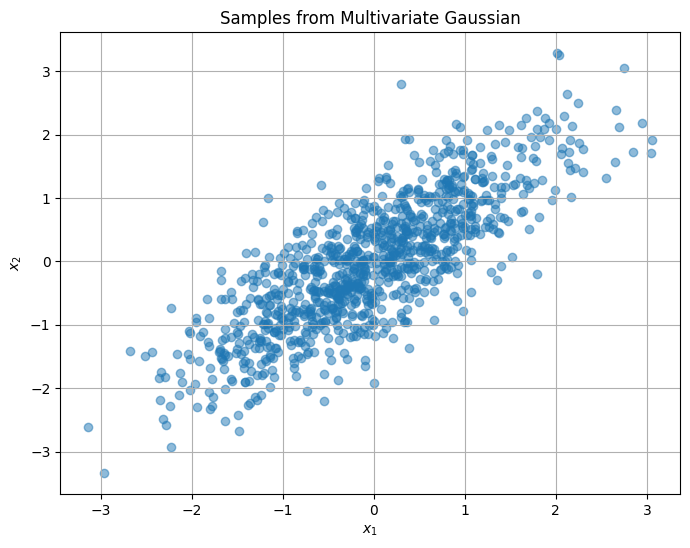

In [2]:
# Sampling from a Multivariate Normal distribution
mu = np.array([0, 0])
cov = np.array([[1, 0.8], [0.8, 1]])
mvn_rv = multivariate_normal(mean=mu, cov=cov)
samples = mvn_rv.rvs(size=1000, random_state=1)
# Plotting Samples
plt.figure(figsize=(8, 6))
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5)
plt.title("Samples from Multivariate Gaussian")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.grid()
plt.show()

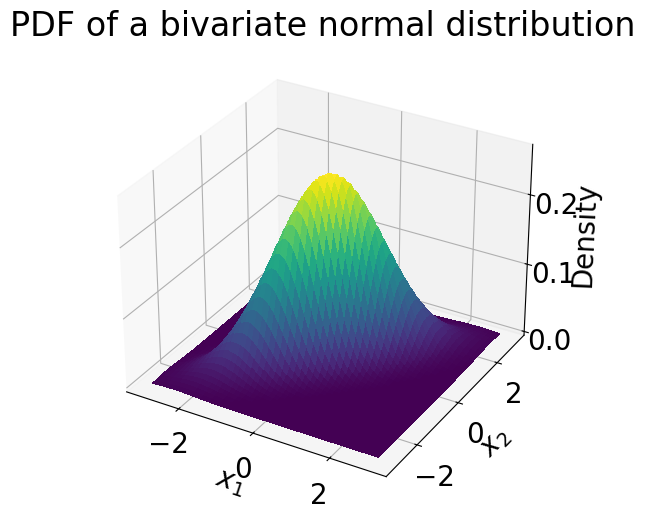

In [5]:
# PDF: 3D graph
#from mpl_toolkits.mplot3d import Axes3D

x1 = np.linspace(-3, 3, 500)
x2 = np.linspace(-3, 3, 500)
X1, X2 = np.meshgrid(x1, x2)
pos = np.dstack((X1, X2))
Z = mvn_rv.pdf(pos)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.plot_surface(X1, X2, Z, cmap='viridis', linewidth=0, antialiased=False)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('Density')
ax.set_title('PDF of a bivariate normal distribution')
plt.show()

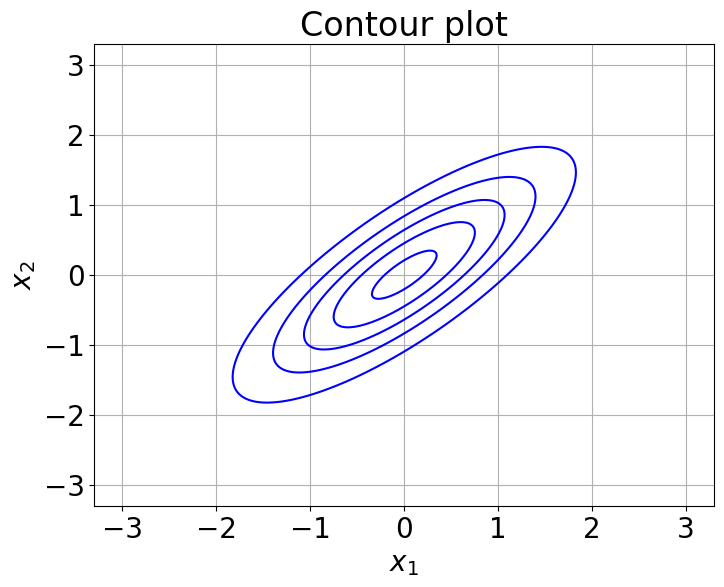

In [5]:
# PDF: Contour
plt.figure(figsize=(8, 6))
plt.contour(X1, X2, Z, levels=5, colors='blue')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.xlim(-3.3, 3.3)
plt.ylim(-3.3, 3.3)
plt.title('Contour plot')
plt.grid()
plt.show()

# 고유값 분해 (Eigenvalue Decomposition)

## 정리
대칭(symmetric)이고 양의 정부호(positive definite)인 행렬 $ C \in \mathbb{R}^{n \times n} $에 대해, 다음과 같은 분해가 성립한다:

$$
C = U \Lambda U^T,
$$

여기서:
- $ U $: 정규 직교 행렬 ($ U^T U = I $), 열 벡터는 $ C $의 고유 벡터이다.
- $ \Lambda $: 대각 행렬 ($ \text{diag}(\lambda_1, \lambda_2, \ldots, \lambda_n) $), $ C $의 고유값을 포함한다.

## 주요 속성
1. **고유값 ($ \lambda_i $)**: 대칭 양정 행렬의 모든 고유값은 실수이며 양수이다.
2. **고유벡터 ($ u_i $)**: 고유벡터는 정규 직교 기저를 형성하도록 선택할 수 있다.
3. **분해**: 공분산 행렬은 고유벡터의 가중 조합으로 표현될 수 있다.


In [6]:
# Illustrative Code: Eigenvalue Decomposition
C = np.array([[4, 2], [2, 3]])
eigenvalues, eigenvectors = np.linalg.eigh(C)
# Reconstruction
reconstructed_C = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
# Print results
print("Original Matrix C:")
print(C)
print("Eigenvalues (λ):")
print(eigenvalues)
print("Eigenvectors (U):")
print(eigenvectors)
print("Reconstructed Matrix (UΛUᵀ):")
print(reconstructed_C)

Original Matrix C:
[[4 2]
 [2 3]]
Eigenvalues (λ):
[1.43844719 5.56155281]
Eigenvectors (U):
[[ 0.61541221 -0.78820544]
 [-0.78820544 -0.61541221]]
Reconstructed Matrix (UΛUᵀ):
[[4. 2.]
 [2. 3.]]


# Location-Dispersion Ellipsoid

## 정의

**Location-Dispersion Ellipsoid**는 다변량 정규 분포의 기하학적 표현으로, 타원체는 다음과 같이 정의된다:

$$
f(x) = \frac{1}{(2\pi)^{d/2} |\Sigma|^{1/2}} \exp\left(-\frac{1}{2} (x - \mu)^T \Sigma^{-1} (x - \mu)\right)
$$

여기서:
- $ \mu $: 평균 벡터 (타원체 중심의 위치)
- $ \Sigma $: 공분산 행렬 (타원체의 형태와 방향을 정의)
- $ \lambda_1, \lambda_2, \ldots, \lambda_d $: $ \Sigma $의 고유값, 축의 길이를 결정
- $ u_1, u_2, \ldots, u_d $: $ \Sigma $의 고유벡터, 타원체의 방향을 정의

공분산 행렬 $ \Sigma $는 다음과 같이 분해될 수 있다:

$$
\Sigma = U \Lambda U^T,
$$

여기서:
- $ U = [u_1, u_2, \ldots, u_d] $: 고유벡터 행렬
- $ \Lambda = \text{diag}(\lambda_1, \lambda_2, \ldots, \lambda_d) $: 고유값의 대각 행렬


In [7]:
# Eigen decomposition
eigenval, eigenvec = np.linalg.eigh(cov)
order = eigenval.argsort()[::-1]  # descending order
eigenval, eigenvec = eigenval[order], eigenvec[:, order]
print(eigenval)
print(eigenvec)

[1.8 0.2]
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


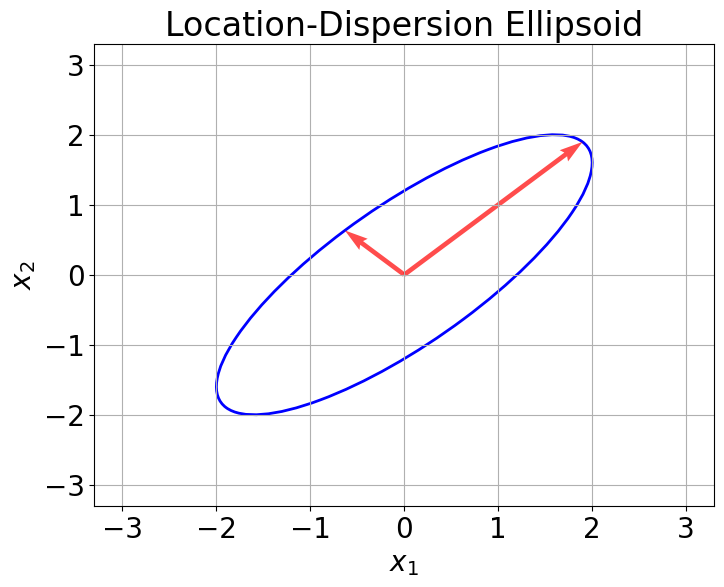

In [8]:
from matplotlib.patches import Ellipse
# Ellipse parameters
width = 4 * np.sqrt(eigenval[0])  # Major axis (4 SD)
height = 4 * np.sqrt(eigenval[1])  # Minor axis (4 SD)
angle = np.degrees(np.arctan2(eigenvec[1,0],eigenvec[0,0]))

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
ellipse = Ellipse(xy=mu, width=width, height=height, angle=angle,
                  edgecolor='blue', facecolor='none', linewidth=2)
ax.add_patch(ellipse)

#plt.contour(X1, X2, Z, levels=5, colors='blue')
for i in range(len(eigenval)):
    vector = eigenvec[:, i] * 2 * np.sqrt(eigenval[i])
    ax.quiver(*mu, *vector, angles='xy', scale_units='xy', scale=1, color='red', alpha=0.7)

# Set axes limits and labels
ax.set_xlim(-3.3, 3.3)
ax.set_ylim(-3.3, 3.3)
ax.set_title("Location-Dispersion Ellipsoid")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
plt.grid()
plt.show()

## 그림 설명
1. **중심**: 타원체는 평균 벡터 $ \mu $를 중심으로 가진다.
2. **축**: 축의 길이와 방향은 공분산 행렬 $ \Sigma $의 고유값 ($ \lambda_1, \lambda_2 $)과 고유벡터 ($ u_1, u_2 $)에 의해 결정된다:
   - 장축은 큰 고유값에 해당한다.
   - 단축은 작은 고유값에 해당한다.
3. **방향**: 타원은 고유벡터에 따라 회전된다.

이 시각화는 다변량 정규분포의 위치와 산포를 적절하게 표현한다.

# 다변량 정규분포의 조건부 및 주변 분포

## 주변 분포

랜덤벡터 $ X \sim N(\mu, \Sigma) $가 다음과 같이 분할될 때:

$$
X = \begin{bmatrix} X_1 \\ X_2 \end{bmatrix}, \quad
\mu = \begin{bmatrix} \mu_1 \\ \mu_2 \end{bmatrix}, \quad
\Sigma = \begin{bmatrix} \Sigma_{11} & \Sigma_{12} \\ \Sigma_{21} & \Sigma_{22} \end{bmatrix},
$$

주변 분포는 다음과 같다:

$$
X_1 \sim N(\mu_1, \Sigma_{11}),
$$
$$
X_2 \sim N(\mu_2, \Sigma_{22}).
$$

### 주요 속성
다변량 정규분포의 부분집합인 주변 분포는 여전히 정규분포를 유지한다.

---

## 조건부 분포

$ X_2 $가 주어졌을 때 $ X_1 $의 조건부 분포는 다음과 같다:

$$
X_1 | X_2 \sim N(\mu_{1|2}, \Sigma_{1|2}),
$$

여기서:
$$
\mu_{1|2} = \mu_1 + \Sigma_{12} \Sigma_{22}^{-1} (X_2 - \mu_2),
$$
$$
\Sigma_{1|2} = \Sigma_{11} - \Sigma_{12} \Sigma_{22}^{-1} \Sigma_{21}.
$$

### 주요 속성
조건부 분포도 정규분포이며, 그 평균과 공분산은 관측된 $ X_2 $ 값에 따라 달라진다.

---

# 핵심 정리
- 주변 분포는 공분산행렬의 대각 블록에만 의존한다.
- 조건부 평균 ($ \mu_{1|2} $)은 $ X_2 $의 관측 값에 따라 이동한다.
- 조건부 분산 ($ \Sigma_{1|2} $)은 $ X_2 $의 관측이 $ X_1 $에 대한 불확실성을 감소시키는 점을 반영한다.


# 다변량 정규분포의 최대 가능도 추정 (MLE)

다변량 정규분포는 다수의 연속형 변수 간의 관계를 모델링하는 데 널리 사용된다. 머신러닝 및 통계학에서 다변량 정규분포의 모수(평균 벡터와 공분산 행렬)를 추정하는 것은 중요한 작업으로, 최대 가능도 추정(Maximum Likelihood Estimation, MLE)은 이러한 모수를 추정하는 대표적인 방법 중 하나이다. 다변량 정규분포는 다음과 같이 정의된다:

$$
\mathbf{X} \sim N_p(\boldsymbol{\mu}, \boldsymbol{\Sigma})
$$

여기서:
- $ \mathbf{X} $는 $ p $-차원의 확률 변수 벡터이다.
- $ \boldsymbol{\mu} \in \mathbb{R}^p $는 평균 벡터이다.
- $ \boldsymbol{\Sigma} \in \mathbb{R}^{p \times p} $는 공분산 행렬로, 양의 정부호(positive definite)이어야 한다.

## 다변량 샘플 데이터

$ n $개의 다변량 샘플 $ \{\mathbf{x}_1, \mathbf{x}_2, \ldots, \mathbf{x}_n\} $가 주어졌을 때, 이들 샘플이 다변량 정규분포를 따른다고 가정할 수 있는 경우가 있다. 대표적인 다변량 샘플의 예로는 [신장,체중] 자료를 고려해볼 수 있다.

## 가능도 함수 (Likelihood Function)

다변량 정규분포의 확률 밀도 함수는 다음과 같다:

$$
f(\mathbf{x}; \boldsymbol{\mu}, \boldsymbol{\Sigma}) = \frac{1}{(2\pi)^{p/2} |\boldsymbol{\Sigma}|^{1/2}} \exp\left( -\frac{1}{2} (\mathbf{x} - \boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu}) \right)
$$

샘플 데이터에 대한 가능도 함수는 모든 샘플의 PDF의 곱으로 정의된다:

$$
L(\boldsymbol{\mu}, \boldsymbol{\Sigma}) = \prod_{i=1}^{n} f(\mathbf{x}_i; \boldsymbol{\mu}, \boldsymbol{\Sigma})
$$

이를 로그 가능도 함수(Log-Likelihood Function)로 변환하면 계산이 쉬워진다:

$$
\ell(\boldsymbol{\mu}, \boldsymbol{\Sigma}) = \log L(\boldsymbol{\mu}, \boldsymbol{\Sigma}) = \sum_{i=1}^{n} \log f(\mathbf{x}_i; \boldsymbol{\mu}, \boldsymbol{\Sigma})
$$

## 최대 가능도 추정 (MLE) 

로그 가능도 함수를 구체적으로 계산하면:

$$
\ell(\boldsymbol{\mu}, \boldsymbol{\Sigma}) = \sum_{i=1}^{n} \left[ -\frac{p}{2} \log(2\pi) - \frac{1}{2} \log |\boldsymbol{\Sigma}| - \frac{1}{2} (\mathbf{x}_i - \boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1} (\mathbf{x}_i - \boldsymbol{\mu}) \right]
$$

이를 정리하면:

$$
\ell(\boldsymbol{\mu}, \boldsymbol{\Sigma}) = -\frac{n p}{2} \log(2\pi) - \frac{n}{2} \log |\boldsymbol{\Sigma}| - \frac{1}{2} \sum_{i=1}^{n} (\mathbf{x}_i - \boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1} (\mathbf{x}_i - \boldsymbol{\mu})
$$


로그 가능도 함수를 최대화하기 위해, 평균 벡터 $ \boldsymbol{\mu} $와 공분산 행렬 $ \boldsymbol{\Sigma} $에 대해 편미분을 수행하고, 이를 0으로 놓고 $ \boldsymbol{\mu} $와 $ \boldsymbol{\Sigma} $의 MLE를 구한다.

##  평균 벡터 $ \boldsymbol{\mu} $에 대한 MLE

로그 가능도 함수를 $ \boldsymbol{\mu} $에 대해 미분하고, 이를 0으로 설정한다:

$$
\frac{\partial \ell}{\partial \boldsymbol{\mu}} = \boldsymbol{\Sigma}^{-1} \sum_{i=1}^{n} (\mathbf{x}_i - \boldsymbol{\mu}) = 0
$$

이를 풀면:

$$
\sum_{i=1}^{n} \mathbf{x}_i = n \boldsymbol{\mu}
$$

따라서, 평균 벡터의 MLE는 샘플의 산술 평균이다:

$$
\hat{\boldsymbol{\mu}} = \frac{1}{n} \sum_{i=1}^{n} \mathbf{x}_i
$$

##  공분산 행렬 $ \boldsymbol{\Sigma} $에 대한 MLE

로그 가능도 함수를 $ \boldsymbol{\Sigma} $에 대해 미분하고, 이를 0으로 설정한다. 여기서는 행렬 미분을 사용한다.

$$
\frac{\partial \ell}{\partial \boldsymbol{\Sigma}} = -\frac{n}{2} \boldsymbol{\Sigma}^{-1} + \frac{1}{2} \boldsymbol{\Sigma}^{-1} \left( \sum_{i=1}^{n} (\mathbf{x}_i - \boldsymbol{\mu})(\mathbf{x}_i - \boldsymbol{\mu})^\top \right) \boldsymbol{\Sigma}^{-1} = 0
$$

양변에 $ \boldsymbol{\Sigma} $를 곱하면:

$$
-\frac{n}{2} I + \frac{1}{2} \sum_{i=1}^{n} (\mathbf{x}_i - \boldsymbol{\mu})(\mathbf{x}_i - \boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1} = 0
$$

이를 정리하면:

$$
\sum_{i=1}^{n} (\mathbf{x}_i - \boldsymbol{\mu})(\mathbf{x}_i - \boldsymbol{\mu})^\top = n \boldsymbol{\Sigma}
$$

따라서, 공분산 행렬의 MLE는 샘플 공분산 행렬이다:

$$
\hat{\boldsymbol{\Sigma}} = \frac{1}{n} \sum_{i=1}^{n} (\mathbf{x}_i - \hat{\boldsymbol{\mu}})(\mathbf{x}_i - \hat{\boldsymbol{\mu}})^\top
$$


In [9]:
# 다변량 정규분포의 실제 평균 벡터와 공분산 행렬 설정 (신장과 체중)
mu_true = np.array([170.0, 70.0])  # 신장 170cm, 체중 70kg
Sigma_true = np.array([[15.0, 5.0],
                       [5.0, 10.0]])  # 공분산 행렬

In [10]:
n_samples = 100
# 다변량 정규분포를 따르는 샘플 데이터 생성 (신장과 체중)
mvn_rv = multivariate_normal(mean=mu_true, cov=Sigma_true)
samples = mvn_rv.rvs(size=n_samples, random_state=3)

In [11]:
# 평균 벡터의 MLE 추정 (샘플 평균)
mu_mle = np.mean(samples, axis=0)
# 공분산 행렬의 MLE 추정 (샘플 공분산), bias=True는 n으로 나눔
Sigma_mle = np.cov(samples, rowvar=False, bias=True) 

In [12]:
# 추정 결과 출력
print("추정된 평균 벡터 (MLE):\n", mu_mle)
print("\n추정된 공분산 행렬 (MLE):\n", Sigma_mle)

추정된 평균 벡터 (MLE):
 [170.48645933  70.26501232]

추정된 공분산 행렬 (MLE):
 [[14.67653023  3.73603481]
 [ 3.73603481  8.54726   ]]


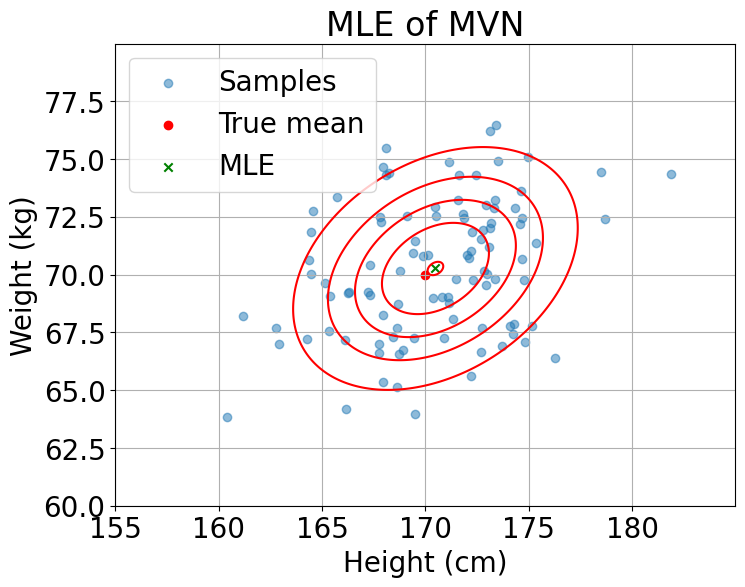

In [13]:
# 시각화: 샘플과 추정된 분포의 등고선
plt.figure(figsize=(8, 6))
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5, label='Samples')

# 추정된 다변량 정규분포의 등고선 그리기
rv = multivariate_normal(mean=mu_mle, cov=Sigma_mle)
x, y = np.mgrid[155:185:.01, 60:80:.01]  # 신장 155-185cm, 체중 60-80kg
pos = np.dstack((x, y))
plt.contour(x, y, rv.pdf(pos), levels=5, colors='red')

# 실제 평균과 MLE 추정된 평균 표시
plt.scatter(mu_true[0], mu_true[1], c='red', marker='o', label='True mean')
plt.scatter(mu_mle[0], mu_mle[1], c='green', marker='x', label='MLE')

plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.title('MLE of MVN')
plt.legend()
plt.grid(True)
plt.show()

# 다항분포

## 정의
다항분포(Multinomial Distribution)는 $k$개의 가능한 결과를 가지는 확률 실험에서 $N$번 독립적으로 시행했을 때, 각 결과가 관찰되는 횟수를 모델링하는 분포.
이항분포(Binomial Distribution)를 셋 이상의 결과범주를 가진 것으로 일반화한 것으로, 각 범주 $ x_1, x_2, \ldots, x_k $를 관측할 확률은 다음과 같다:

## 확률 질량 함수 (PMF)

$$
P(\mathbf{X} = \mathbf{x}) = \frac{N!}{x_1! x_2! \ldots x_k!} \prod_{i=1}^k p_i^{x_i}
$$

- $ N $: 총 시행 횟수
- $ p_i $: $ i $번째 결과의 확률 ($ \sum p_i = 1 $)
- $ x_i $: $ i $번째 결과의 횟수 ($ \sum x_i = N $)

## 기대값, 분산, 공분산
$\mathbf{X} = [X_1 , X_2 , \cdots, X_k]^T \sim \text{Multi}(p_1, p_2 , \cdots, p_k )$일 때,
- 랜덤변수 $ X_i $의 기대값:
$$
\text{E}[X_i] = N p_i.
$$

- 랜덤변수 $ X_i $의 분산:
$$
\text{Var}(X_i) = N p_i (1 - p_i).
$$

- 랜덤변수 $ X_i $, $ X_j $($i \neq j $)의 공분산: 
$$
\text{Cov}(X_i, X_j) = -N p_i p_j.
$$

## 공분산 행렬 (Covariance Matrix)

다항분포 랜덤벡터 $ \mathbf{X} $에 대한 공분산 행렬 $ \Sigma $는 다음과 같이 정의된다:
$$
\Sigma = 
\begin{bmatrix}
\text{Var}(X_1) & \text{Cov}(X_1, X_2) & \cdots & \text{Cov}(X_1, X_k) \\
\text{Cov}(X_2, X_1) & \text{Var}(X_2) & \cdots & \text{Cov}(X_2, X_k) \\
\vdots & \vdots & \ddots & \vdots \\
\text{Cov}(X_k, X_1) & \text{Cov}(X_k, X_2) & \cdots & \text{Var}(X_k)
\end{bmatrix},
$$

where: 
- $ \text{Var}(X_i) = N p_i (1 - p_i) $,
- $ \text{Cov}(X_i, X_j) = -N p_i p_j $.



## 사용 예제
1. 주사위를 여러 번 굴리는 경우
2. 다중클래스 분류


In [43]:
# Illustrative Code: Multinomial Sampling
from scipy.stats import multinomial
# Parameters
N = 6  # Number of trials
probs = [1/6]*6 
# 6번씩 던진 샘플을 5개 얻었을 때
outcomes = multinomial.rvs(n=N, p=probs,
                           size=5, random_state=1)
print("Multinomial samples:\n", outcomes)

Multinomial samples:
 [[1 1 0 1 1 2]
 [0 0 1 1 2 2]
 [1 1 0 2 0 2]
 [1 1 1 0 1 2]
 [2 2 0 1 1 0]]


In [45]:
# 표본 평균
sample_mean = np.mean(outcomes, axis=0)
# 표본 공분산
sample_cov = np.cov(outcomes, rowvar=False)
print(sample_mean)
print(sample_cov)

[1.  1.  0.4 1.  1.  1.6]
[[ 0.5   0.5  -0.25  0.   -0.25 -0.5 ]
 [ 0.5   0.5  -0.25  0.   -0.25 -0.5 ]
 [-0.25 -0.25  0.3  -0.25  0.25  0.2 ]
 [ 0.    0.   -0.25  0.5  -0.25  0.  ]
 [-0.25 -0.25  0.25 -0.25  0.5   0.  ]
 [-0.5  -0.5   0.2   0.    0.    0.8 ]]


In [46]:
# 특정 결과의 확률 계산
x1 = [1, 1, 1, 1, 1, 1]
x2 = [2, 2, 2, 0, 0, 0]
prob1 = multinomial.pmf(x1, n=N, p=probs)
prob2 = multinomial.pmf(x2, n=N, p=probs)
print(prob1)
print(prob2)

0.01543209876543212
0.0019290123456790144


# 지수족 분포

## 정의
확률분포함수가 다음과 같은 형태로 표현될 수 있다면, 그 분포는 지수족 분포(Exponential Family)에 속한다:

$$
f(x | \eta) = h(x) \exp\left( \eta^T u(x) - A(\eta) \right),
$$

- $ \eta $: 자연모수(natural parameter) 벡터
- $ u(x) $: 충분통계량(sufficient statistics) 벡터
- $ A(\eta) $: 로그분할함수(log-partition function)
- $ h(x) $: 기저 함수(base function)

## 속성

### 1. 로그분할함수 ($ A(\eta) $)
로그분할함수 $ A(\eta) $는 다음과 같이 정의된다:
$$
A(\eta) = \log \int h(x) \exp\left(\eta^T u(x)\right) dx.
$$

### 2. 충분통계량의 평균
$ A(\eta) $를 자연모수 $ \eta $에 대해 미분하면 $ u(X) $의 기대값을 구할 수 있다:
$$
\nabla_\eta A(\eta) = \mathbb{E}[u(X)].
$$

### 3. 충분통계량의 분산
$ A(\eta) $의 두 번째 미분(헤시안)은 $ u(X) $의 분산(공분산)을 구할 수 있다:
$$
\nabla^2_\eta A(\eta) = \text{Cov}[u(X)].
$$

## 지수족 분포의 예

### 1. 정규분포(단변량)
정규분포 랜덤변수 $ X \sim N(\mu, \sigma^2)$의 PDF는 다음과 같다:
$$
f(x | \mu, \sigma^2) = \frac{1}{\sqrt{2\pi \sigma^2}} \exp\left(-\frac{1}{2\sigma^2} (x - \mu)^2\right).
$$

지수족 분포 형태로 다시 쓰면:
$$
f(x | \eta) = \exp\left(\eta_1 x + \eta_2 x^2 - A(\eta)\right),
$$

- 충분통계량: $ u(x) = [x, x^2]^T $
- 자연모수: $ \eta = \left[\frac{\mu}{\sigma^2}, -\frac{1}{2\sigma^2}\right]^T $
- 로그분할함수: $ A(\eta) = \frac{\mu^2}{2\sigma^2} + \frac{1}{2}\log(2\pi\sigma^2) = -\frac{\eta_1^2}{4\eta_2}+\frac{1}{2}\log(-\frac{\pi}{\eta_2}) $
- 기저함수: $ h(x) = 1 $


---


### 2. 베르누이분포
베르누이 랜덤변수 $ X \sim \text{Bernoulli}(\mu) $의 PMF는 다음과 같다:
$$
P(X = x) = \mu^x (1 - \mu)^{1 - x}.
$$

지수족 분포 형태로 다시 쓰면:
$$
P(X = x) = \exp\left(x \log\left(\frac{\mu}{1-\mu}\right) + \log(1 - \mu)\right).
$$

- 충분통계량: $ u(x) = x $
- 자연모수: $ \eta = \log\left(\frac{\mu}{1 - \mu}\right) $
- 로그분할함수: $ A(\eta) = -\log(1 - \mu) = \log(1 + e^{\eta})$
- 기저함수: $ h(x) = 1 $


---


### 3. 포아송분포
포아송 랜덤변수 $ X \sim \text{Poisson}(\lambda) $의 PMF는 다음과 같다:
$$
P(X = x) = \frac{\lambda^x e^{-\lambda}}{x!}.
$$

지수족 분포 형태로 다시 쓰면:
$$
P(X = x) = \exp\left(x \log(\lambda) - \lambda - \log(x!)\right).
$$

- 충분통계량: $ u(x) = x $
- 자연모수: $ \eta = \log(\lambda) $
- 로그분할함수: $ A(\eta) = \lambda = e^{\eta} $
- 기저함수: $ h(x) = \frac{1}{x!} $



## 지수족 분포가 아닌 예

### 1. 균등분포(연속)
균등분포 랜덤변수 $ X \sim \text{Unif}(a, b)$의 PDF는 다음과 같다:
$$
f(x | a, b) = 
\begin{cases} 
\frac{1}{b - a} & \text{if } a \leq x \leq b, \\
0 & \text{otherwise}.
\end{cases}
$$

#### 균등분포는 지수족 분포에 속하지 않는다:
- PDF가 자연모수와 충분통계량 $ u(x) $의 선형 결합 형태로 표현되지 않는다.
- 지수족 분포의 형태인 $ h(x) \exp(\eta^T u(x) - A(\eta)) $로 표현할 수 없다.


---
### 2. 균등분포(이산)
균등분포 랜덤변수 $ X \sim \text{Unif}(a, b)$의 PMF는 다음과 같다:
$$
P(X=x)= \frac{1}{n}, \quad  x \in \{a, a+1, \cdots, b\}.
$$

#### 균등분포는 지수족 분포에 속하지 않는다:
- PDF가 자연모수와 충분통계량 $ u(x) $의 선형 결합 형태로 표현되지 않는다.
- 지수족 분포의 형태인 $ h(x) \exp(\eta^T u(x) - A(\eta)) $로 표현할 수 없다.

---


### 3. 이항분포(N을 모수로 포함할 경우)
이항분포 랜덤변수 $ X \sim \text{Binomial}(N, p) $의 PMF는 다음과 같다:
$$
P(X = x) = \binom{N}{x} p^x (1 - p)^{N - x}.
$$

#### $N$을 모수로 볼 경우, 이항분포는 지수족 분포에 속하지 않는다:
- PDF가 자연모수와 충분통계량 $ u(x) $의 선형 결합 형태로 표현되지 않는다.
- 지수족 분포의 형태인 $ h(x) \exp(\eta^T u(x) - A(\eta)) $로 표현할 수 없다.

#### $p$만 모수로 볼 경우, 지수족 분포 형태로 다시 쓰면:
$$
P(X = x) = \binom{N}{x} \exp\left(x \log\left(\frac{p}{1 - p}\right) + N \log(1 - p) \right).
$$

- 충분 통계량: $ u(x) = x $
- 자연모수: $ \eta = \log\left(\frac{p}{1 - p}\right) $
- 로그분할함수: $ A(\eta) = -N \log(1 -p) =N \log(1 + e^{\eta}) $
- 기저함수: $ h(x) = \binom{N}{x} $

## 참고: 지수족 분포에서의 최대 가능도 추정 (MLE)

독립 동일 분포(i.i.d.)인 $ N $개의 관측치 $ X = \{x_1, x_2, \ldots, x_N\} $가 주어졌을 때, 자연모수 $ \eta $에 대한 로그 가능도는 다음과 같다:
$$
\ell(\eta) = \sum_{n=1}^N \left[\log h(x_n) + \eta^T u(x_n) - A(\eta)\right].
$$

### $ \eta_{ML} $ 찾기
로그 가능도를 최대화하면:
$$
\frac{\partial \ell(\eta)}{\partial \eta} = 0 \implies \mathbb{E}[u(X)] = \frac{1}{N} \sum_{n=1}^N u(x_n).
$$

최대 가능도 추정치 $ \eta_{ML} $는 이 방정식을 풀어서 얻는다.

# 정리

1. 다변량 정규분포는 변수 간의 상관관계를 포착하며 real-world 데이터 모델링에 핵심적인 역할을 한다.
2. 다항분포는 이항분포의 확장으로 두 개 이상의 범주를 가진 사건의 확률을 모델링하는 데 사용된다.
3. 지수족 분포는 다양한 분포를 하나의 프레임워크 아래 통합하여 추론과 분석을 단순화한다.
